<a href="https://colab.research.google.com/github/Albertoromero-01/Inteligencia_Artificial/blob/main/AF6_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Actividad 6: Aprendizaje supervizado, árbol de decisión

In [ ]:
# Equipo:
# N5 José Alberto Romero Francisco 2000506
# N5 Daniel Alessandro Campa Torres 2095970
# V6 Jaidy Rubi Gil Briones 2099573
# V6 David Alvarado Cantú 2094638
# V6 Azael Francisco Manuel 2101550
import matplotlib.pyplot as plt  # Generar gráficos
from sklearn.model_selection import train_test_split  # Dividir datos en train/test
from sklearn.tree import DecisionTreeClassifier  # Modelo de árbol de decisión
from sklearn.metrics import accuracy_score, classification_report  # Evalúa modelos de clasificación
from sklearn import tree  # Visualización de árboles de decisión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Matriz de confusión
from sklearn.preprocessing import LabelEncoder  # Codificar etiquetas de texto a numéricas
import seaborn as sns  # Visualización de datos estadísticos
import numpy as np  # Generar arreglos
import pandas as pd  # Cargar datasets
from google.colab import drive # Carga de dataset por Drive
drive.mount('/content/drive')
dataset = '/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv'  #Ruta del data set
data = pd.read_csv(dataset)  # Carga el dataset

In [14]:
X = data.drop(columns=['target']).values # Data a entrenar (todo menos la columna 'target')
y = data['target'].values # Resultado a entrenar
len(y) # Longitud de "y"

569

In [17]:
enc = LabelEncoder() # Convierte etiquetas de texto en números enteros
y = enc.fit_transform(y)  # La variable "y" ahora es un array numérico
target_names = enc.classes_  # Nombres de las clases en "y"
print("Nombres de las clases:", target_names)

Nombres de las clases: [0 1]


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100) # Dividir el dataset en conjuntos de train (80%) y test (20%)

In [20]:
clf = DecisionTreeClassifier() # Crea un clasificador de árbol de decisión
clf.fit(X_train, y_train) # Ajusta el modelo a los datos, minimiza los errores

DecisionTreeClassifier()

In [21]:
train_accuracy = clf.score(X_train, y_train) # Exactitud del modelo en el entrenamiento
print(train_accuracy)

1.0


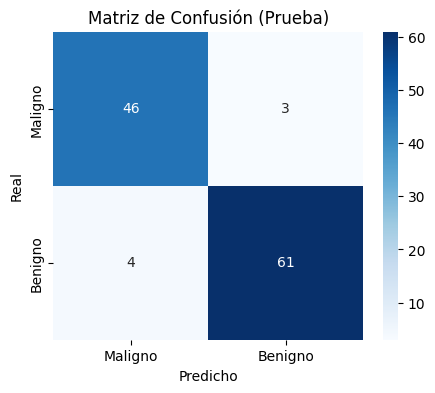

In [23]:
y_pred = clf.predict(X_test) # Realiza predicciones con el modelo entrenado usando los datos de test (20%)
conf_matrix = confusion_matrix(y_test, y_pred) # Genera la matriz de confusión comparando valores reales vs predicciones
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Maligno', 'Benigno'], yticklabels=['Maligno', 'Benigno']) # Crear mapa de calor
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión (Prueba)")
plt.show()

In [24]:
print(y_pred[1])
print(y_test[1])

1
1


In [25]:
print(y_pred[20])
print(y_test[20])

0
1


In [26]:
print(y_pred[-1])
print(y_test[-1])

1
1


In [28]:
accuracy = accuracy_score(y_test, y_pred) # Calcula la exactitud del modelo comparando las etiquetas reales con las predichas
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=[str(x) for x in target_names]))

Accuracy: 0.9385964912280702
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93        49
           1       0.95      0.94      0.95        65

    accuracy                           0.94       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.94      0.94      0.94       114



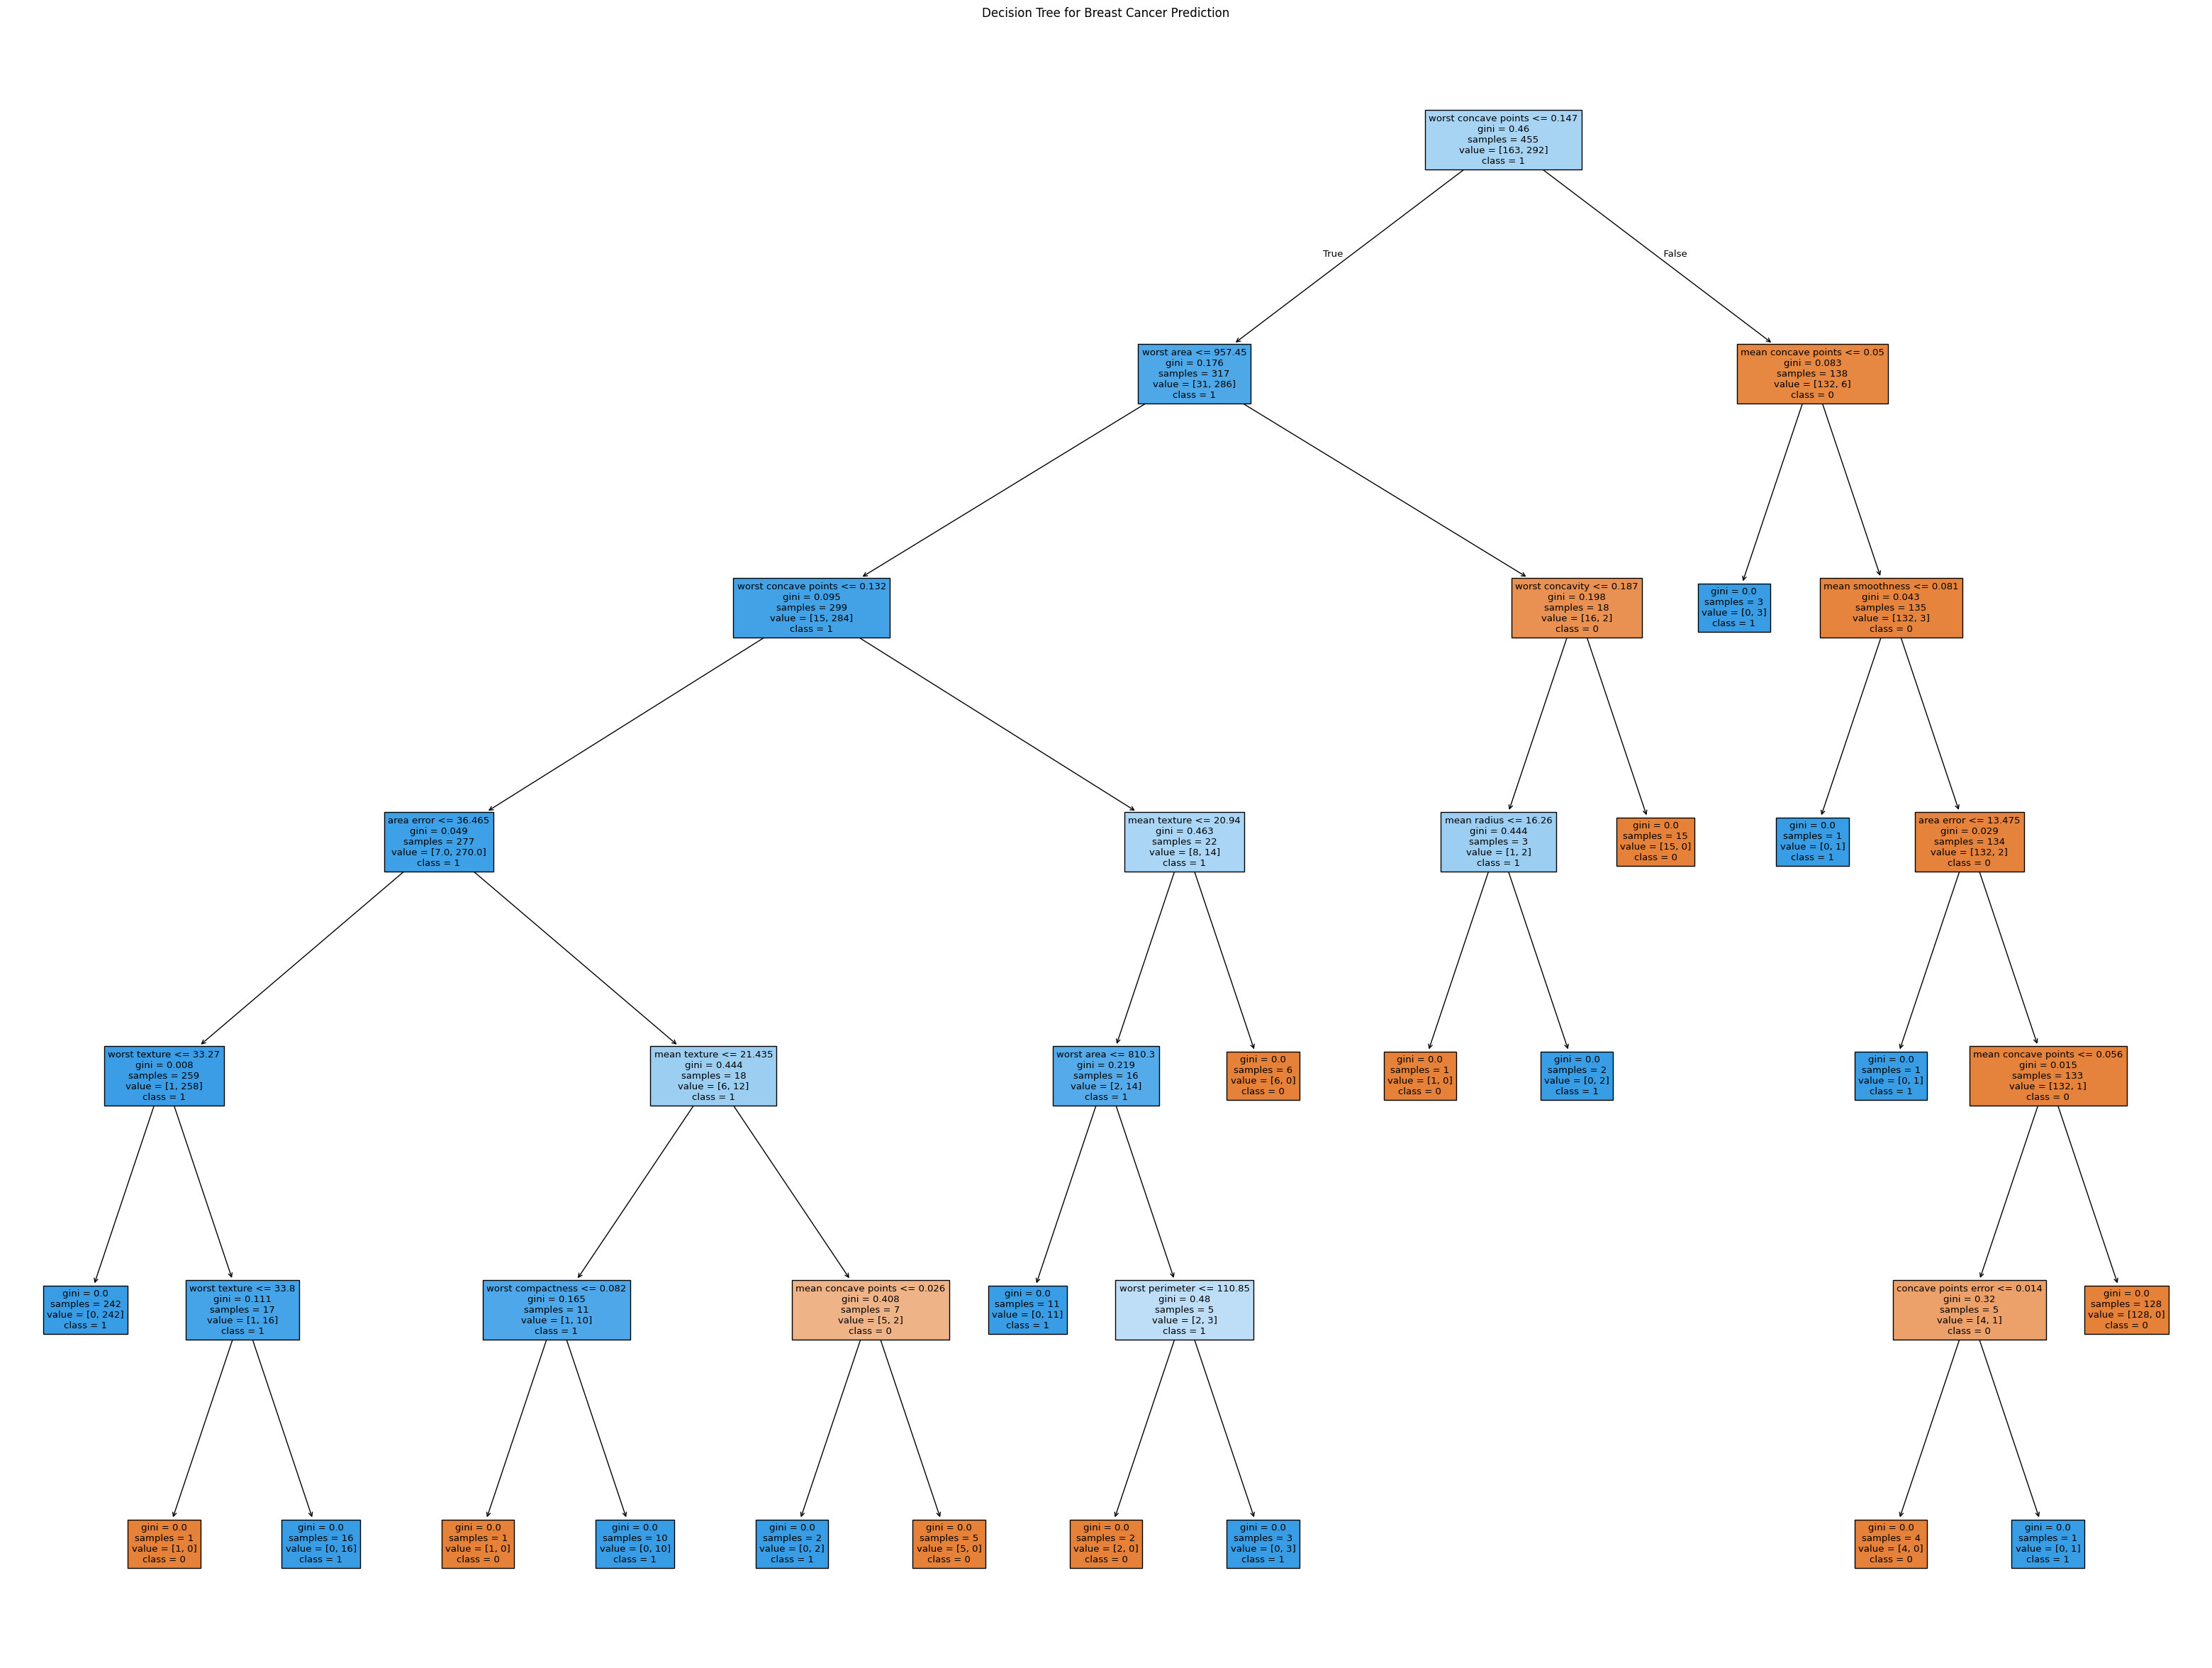

In [31]:
plt.figure(figsize=(40, 30))  # Incrementar el tamaño para mejor resolución
feature_names = data.drop(columns=['target']).columns.tolist()
tree.plot_tree(clf, feature_names=feature_names, filled=True, class_names=[str(x) for x in target_names]) # Crear árbol de decisiones
plt.title("Decision Tree for Breast Cancer Prediction")
plt.savefig("decision_tree.png", dpi=300)  # Incrementar el DPI para mejor resolución
plt.show()